In [69]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [70]:
# 1. Wczytaj dane z plików countries.geojson i population_density.geojson.
countries = gpd.read_file("countries.geojson")
population_density = gpd.read_file("population_density.geojson")

In [71]:
# 2. Przeprowadź projekcję danych na EPSG:3857 (Web Mercator).
countries = countries.to_crs(epsg = 3857)
population_density = population_density.to_crs(epsg = 3857)

In [72]:
# 3. Oblicz procentową zmianę gęstości zaludnienia między rokiem 2014 a rokiem 2017.
population_density["dens_change"] = ((population_density["PopDen_PD2017"] - population_density["PopDen_PD2014"]) / population_density["PopDen_PD2014"]) * 100

In [73]:
# 4. Przeprowadź klasyfikację procentowej zmiany gęstości zaludnienia na przedziały o wartościach -5, 0, 5, 10.
bins = [-float('inf'),-5, 0, 5, 10, float("inf")]
labels = ["< -5%", "-5% - 0%", "0% - 5%", "5% - 10%", "> 10%"]
population_density["change_class"] = pd.cut(population_density["dens_change"], bins=bins, labels=labels)

<Axes: >

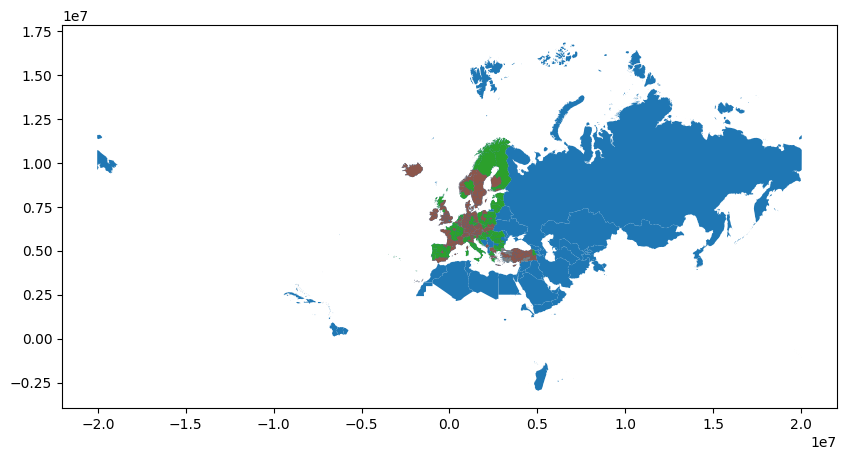

In [74]:
# 5. Na mapie zamieść dane dotyczące krajów i gęstości zaludnienia (wykorzystując rezultaty klasyfikacji).
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
countries.plot(ax=ax)
population_density.plot(ax=ax, column='change_class')

<Axes: >

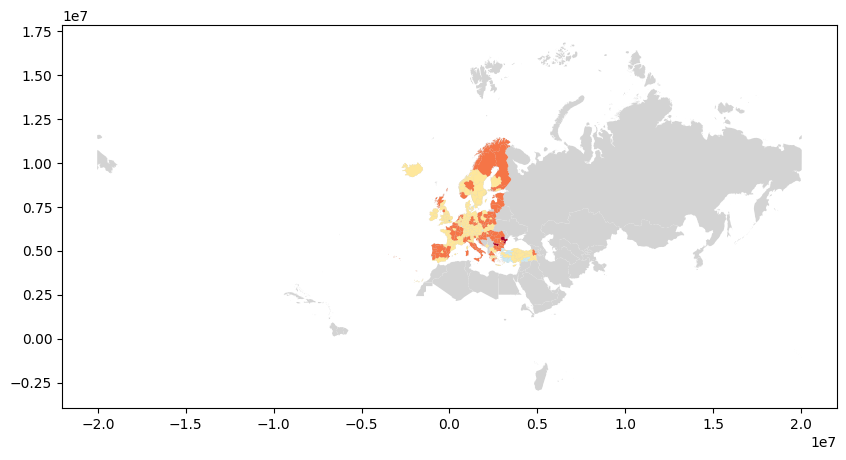

In [75]:
# 6. Dobierz mapę kolorów.
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
countries.plot(ax=ax, color='lightgrey')
population_density.plot(ax=ax, column='change_class', cmap='RdYlBu', vmin=0, vmax=4.7)

(3100000.0, 11600000.0)

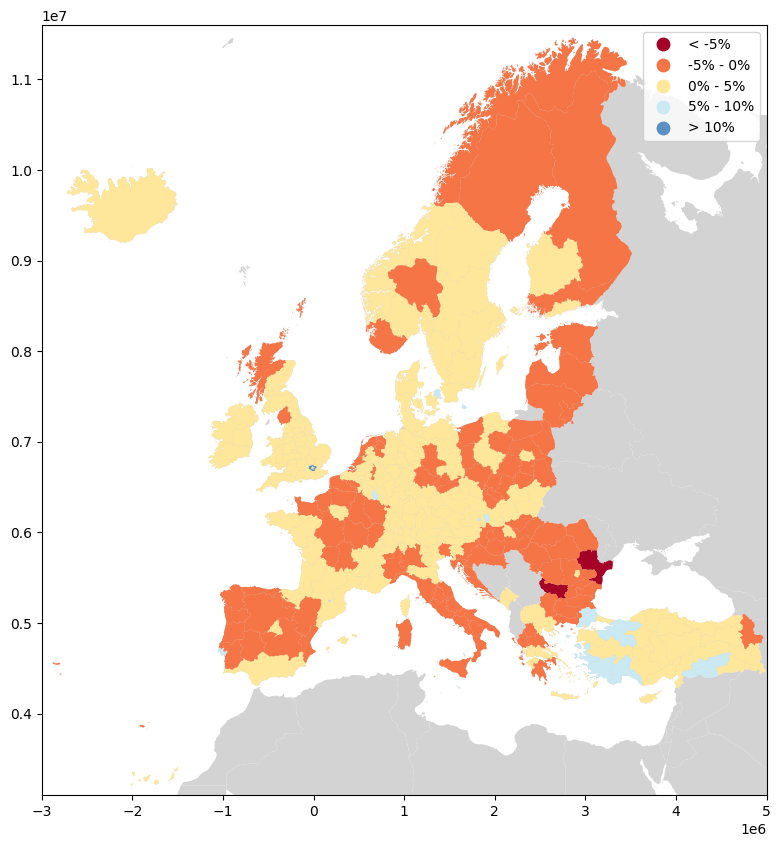

In [76]:
# 7. Dopasuj współrzędne geograficzne tak, aby mapa prezentowała przede wszystkim kraje europejskie.
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
countries.plot(ax=ax, color='lightgrey')
population_density.plot(ax=ax, column='change_class', cmap='RdYlBu', vmin=0, vmax=4.7, legend=True)
ax.set_xlim(-3000000, 5000000)
ax.set_ylim(3100000, 11600000)

(3100000.0, 11600000.0)

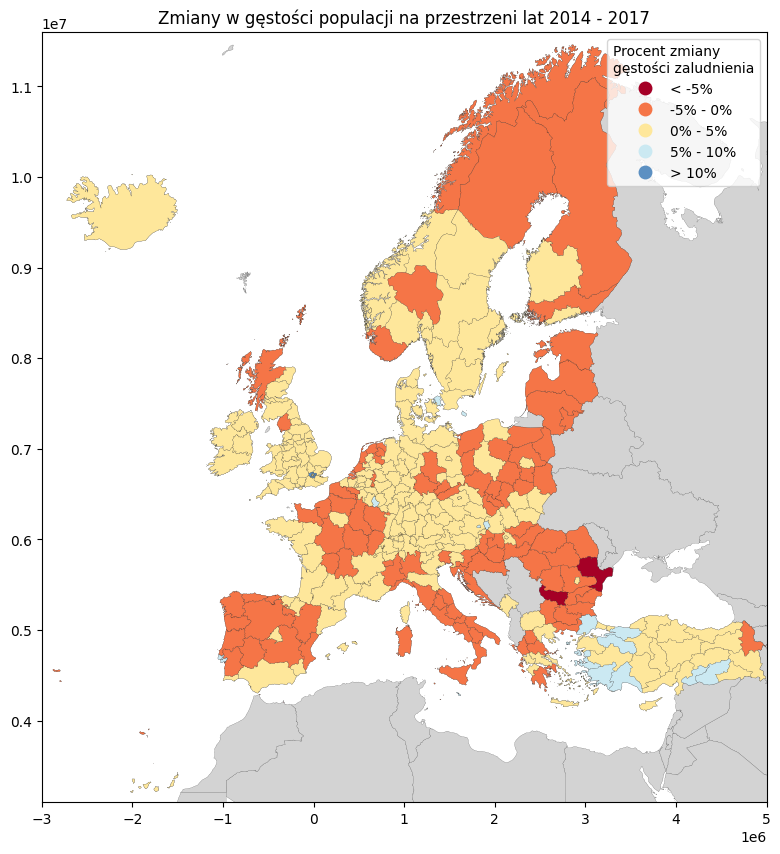

In [77]:
# 8. Zadbaj o czytelność i przejrzystość mapy, m.in. poprzez wyświetlenie tytułu wykresu i legendy, a także dobór kolorów pozostałych elementów.
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
countries.plot(ax=ax, linewidth=0.1, edgecolor='black', color='lightgrey')
population_density.plot(ax=ax, column='change_class', cmap='RdYlBu', vmin=0, vmax=4.7, legend=True,
                        legend_kwds={'title': 'Procent zmiany \ngęstości zaludnienia'}, linewidth=0.1, edgecolor='black')
ax.set_title('Zmiany w gęstości populacji na przestrzeni lat 2014 - 2017')
ax.set_xlim(-3000000, 5000000)
ax.set_ylim(3100000, 11600000)

Text(0.02, 0.05, 'Data source: Eurostat')

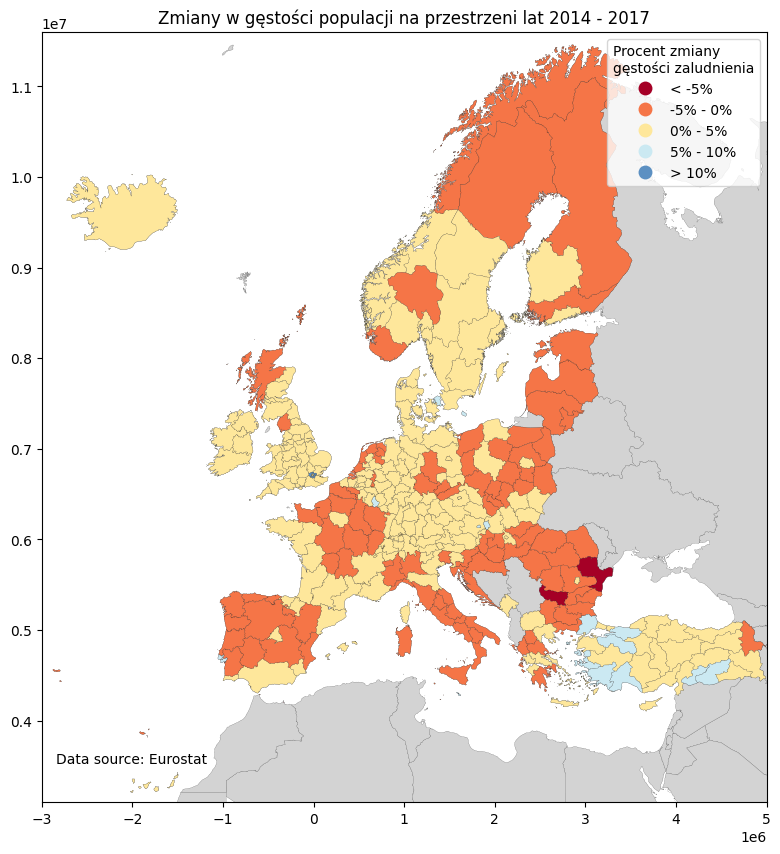

In [78]:
# 9. Umieść informację o źródle danych w lewym dolnym rogu wykresu ("Data source: Eurostat").
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
countries.plot(ax=ax, linewidth=0.1, edgecolor='black', color='lightgrey')
population_density.plot(ax=ax, column='change_class', cmap='RdYlBu', vmin=0, vmax=4.7, legend=True,
                        legend_kwds={'title': 'Procent zmiany \ngęstości zaludnienia'}, linewidth=0.1, edgecolor='black')
ax.set_title('Zmiany w gęstości populacji na przestrzeni lat 2014 - 2017')
ax.set_xlim(-3000000, 5000000)
ax.set_ylim(3100000, 11600000)
ax.text(x=0.02, y=0.05, s="Data source: Eurostat", transform=plt.gca().transAxes)

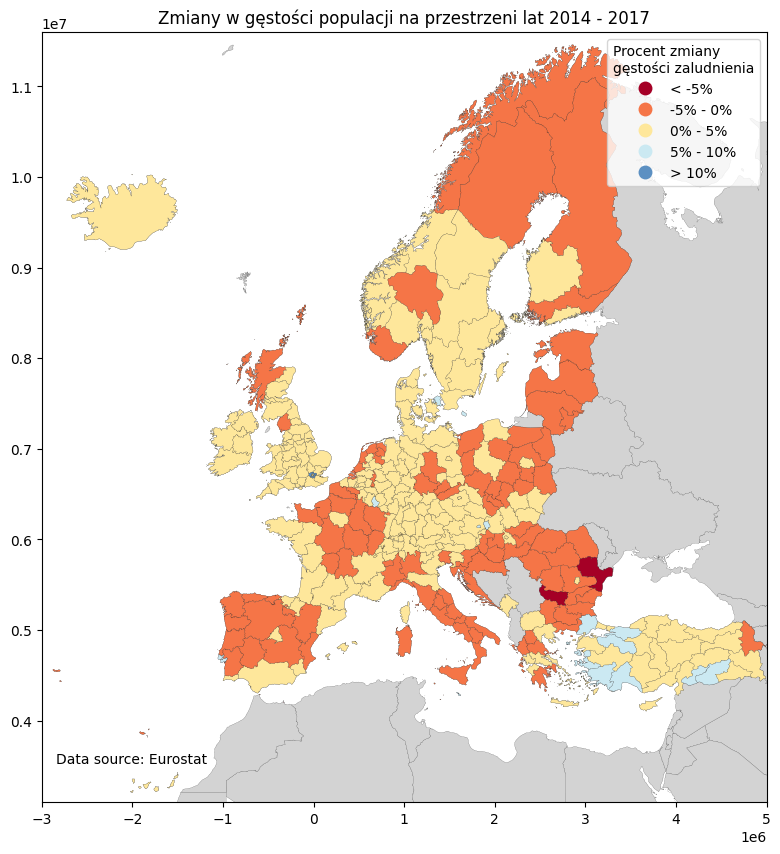

In [80]:
# 10. Zapisz mapę do pliku w formacie PNG.
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
countries.plot(ax=ax, linewidth=0.1, edgecolor='black', color='lightgrey')
population_density.plot(ax=ax, column='change_class', cmap='RdYlBu', vmin=0, vmax=4.7, legend=True,
                        legend_kwds={'title': 'Procent zmiany \ngęstości zaludnienia'}, linewidth=0.1, edgecolor='black')
ax.set_title('Zmiany w gęstości populacji na przestrzeni lat 2014 - 2017')
ax.set_xlim(-3000000, 5000000)
ax.set_ylim(3100000, 11600000)
ax.text(x=0.02, y=0.05, s="Data source: Eurostat", transform=plt.gca().transAxes)
plt.savefig("test.png")